### Defining parameters for model
In the GPT_CONFIG_124M dictionary, we use concise variable names for clarity and to
prevent long lines of code:
* vocab_size refers to a vocabulary of 50,257 words, as used by the BPE tokenizer.
* context_length denotes the maximum number of input tokens the model can
handle via the positional embeddings.
* emb_dim represents the embedding size, transforming each token into a 768-
dimensional vector.
* n_heads indicates the count of attention heads in the multi-head attention
mechanism.
* n_layers specifies the number of transformer blocks in the model.
* drop_rate indicates the intensity of the dropout mechanism (0.1 implies a 10%
random drop out of hidden units) to prevent overfitting.
* qkv_bias determines whether to include a bias vector in the Linear layers of
the multi-head attention for query, key, and value computations. We have
disabled this, following the norms of modern LLMs.

In [46]:
GPT_CONFIG_124M = {
"vocab_size": 50257, # Vocabulary size
"context_length": 1024, # Context length
"emb_dim": 768, # Embedding dimension
"n_heads": 12, # Number of attention heads
"n_layers": 12, # Number of layers
"drop_rate": 0.1, # Dropout rate
"qkv_bias": False # Query-Key-Value bias
}

### 1. GPT Backbone

In [47]:
import torch
import torch.nn as nn

# A placeholder GPT model architecture class
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
                for _ in range(cfg["n_layers"])]
            )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    def forward(self, x):
        return x


In [48]:
# Prepare input data and tokenize it
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


### 2. Normalization Layer (LayerNorm):

The main idea behind layer normalization is to adjust the activa-
tions (outputs) of a neural network layer to have a mean of 0 and a variance of 1, also
known as unit variance. This adjustment speeds up the convergence to effective
weights and ensures consistent, reliable training. In GPT-2 and modern transformer
architectures, layer normalization is typically applied before and after the multi-head
attention module.

This specific implementation of layer normalization operates on the last dimension of
the input tensor x, which represents the embedding dimension (emb_dim). The vari-
able eps is a small constant (epsilon) added to the variance to prevent division by zero
during normalization. The scale and shift are two trainable parameters (of the
same dimension as the input) that the LLM automatically adjusts during training if it
is determined that doing so would improve the model’s performance on its training
task. This allows the model to learn appropriate scaling and shifting that best suit the
data it is processing.

In [49]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

### 3. GELU Activation Function:

Historically, the ReLU (Rectified Linear Unit) activation function has been commonly used in deep learning
due to its simplicity and effectiveness across various neural network architectures.
However, in LLMs, several other activation functions are employed beyond the tradi-
tional ReLU.

GELU(Gaussian error linear unit) and SwiGLU (Swish-gated linear unit) are more complex and smooth activation functions incorpo-
rating Gaussian and sigmoid-gated linear units, respectively. They offer improved per-
formance for deep learning models, unlike the simpler ReLU.

The smoothness of GELU can lead to better optimization properties during training,
as it allows for more nuanced adjustments to the model’s parameters.
Moreover, unlike ReLU, which outputs zero for any negative input, GELU
allows for a small, non-zero output for negative values. This characteristic means that
during the training process, neurons that receive negative input can still contribute to
the learning process, albeit to a lesser extent than positive inputs.


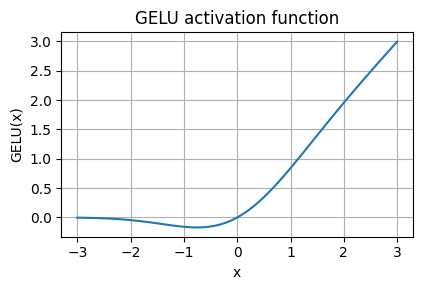

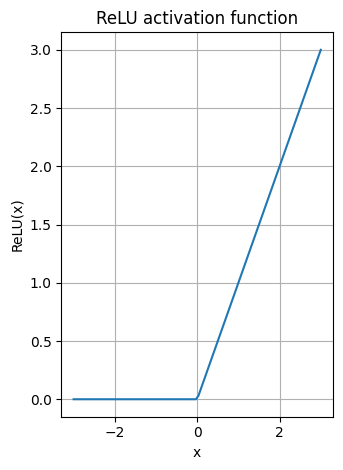

In [50]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
        ))

import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 4. Feed forward 

In the 124-million-parameter GPT model, it receives the input batches with tokens that have an embedding size of 768 each via the GPT_CONFIG_124M dictionary where GPT_CONFIG_ 124M["emb_dim"] = 768.

In [51]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )
    def forward(self, x):
        return self.layers(x)

### 5. Shortcut connections

The "deep" in deep learning refers to the fact that these networks are made of multiple hidden layers of artificial neurons stacked together to process information step by step.
When we train this network, we want it to learn from its mistakes. It does this using gradients, which are essentially mathematical feedback signals that guide the weight updates during training. After the network makes a prediction at the very last layer, this feedback is sent backward through all the preceding layers so each layer can adjust its internal settings to do better next time.
Here is where the vanishing gradient problem occurs: As these feedback signals travel backward through a deep network, they become progressively smaller as they propagate backward through the layers. By the time the feedback reaches the earliest layers of the network, the signal has shrunk so much that it practically vanishes. When this happens, the network has difficulty learning the underlying patterns in the data, leading to unstable and ineffective training because the early layers never get the instructions they need to improve.
(Note: To make this easier to picture, I will use an assembly line analogy below that is not found in your sources, but helps illustrate the concepts they describe. You may want to independently verify this analogy.)
Imagine a long assembly line of 100 workers (the layers). The manager at the end of the line inspects the final product, finds an error, and tells worker #100 how to fix it. Worker #100 whispers the feedback to #99, who whispers it to #98, and so on. By the time the whisper reaches worker #1 at the start of the line, the message is completely lost. Worker #1 learns nothing. This is the vanishing gradient problem.
Shortcut connections (also known as skip or residual connections) are the engineering solution to this problem. Instead of forcing the feedback to pass through every single layer one by one, a shortcut connection creates an alternative, shorter path for the gradient to flow through the network by skipping one or more layers.

Returning to our analogy, a shortcut connection is like giving the manager a direct phone line to worker #50, worker #25, and worker #1. The message bypasses the long, noisy chain of whispers.
By physically adding the output of an earlier layer directly to a much later layer, these shortcuts preserve the flow of gradients during the backward pass in training

### 6. Transformer Block

When a transformer block processes an input sequence, each element in the sequence (for example, a word or subword token) is represented by a fixed-size vector (in this case, 768 dimensions). The operations within the transformer block, including multi-head attention and feed forward layers, are designed to transform these vectors in a way that preserves their dimensionality.
The idea is that the self-attention mechanism in the multi-head attention block identifies and analyzes relationships between elements in the input sequence. In contrast, the feed forward network modifies the data individually at each position. This combination not only enables a more nuanced understanding and processing of the input but also enhances the model’s overall capacity for handling complex data patterns.


In [54]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = nn.MultiheadAttention(
            embed_dim=cfg["emb_dim"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            bias=cfg["qkv_bias"],
            batch_first=True,
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        seq_len = x.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(
            seq_len, device=x.device, dtype=x.dtype
        )
        x, _ = self.att(x, x, x, attn_mask=causal_mask, need_weights=False)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
